# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

Separamos los datasets en DF, basicamente los categorizamos, podemos notar que tenemos archivos.csv, por tanto utilizaremos read_csv para leer los archivos correctamente

In [1]:
import pandas as pd # importar librerías

In [2]:
df_orders = pd.read_csv("/datasets/instacart_orders.csv", sep=';')
df_products = pd.read_csv("/datasets/products.csv", sep=';')
df_aisles = pd.read_csv("/datasets/aisles.csv", sep=';')
df_departments = pd.read_csv("/datasets/departments.csv", sep=';')
df_order_products = pd.read_csv("/datasets/order_products.csv", sep=';') # leer conjuntos de datos en los DataFrames

In [3]:
df_orders.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [4]:
df_products.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [5]:
df_aisles.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [6]:
df_departments.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [7]:
df_order_products.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

Despues de sacar informacion de los DF, tenemos que la mayoria de los Dtype son int64,  en todos los DF, tenemos tambien tipo object y float64, y podemos notar que en days_since_prior_order, product_name hay valores nulos, tambien en add_to_cart_order y days_since_prior_order son tipo float64

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

Hay que convertir los datos float 64 a int64, para datos faltantes podemos mantenerlos como NaN, tambien hay que hacer una revision si existen datos duplicados y eliminarlos para que no afecten los resultados del analisis

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
df_orders.duplicated().sum()

15

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

Si, hay 15 filas duplicadas, el mismo pedido fue registrado 2 veces, probablemente en el mismo momento del dia.

In [9]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
pedidos_miercoles_2am = df_orders[(df_orders['order_dow'] == 3) & (df_orders['order_hour_of_day'] == 2)]

print(f"Total de pedidos del miércoles a las 2 AM: {len(pedidos_miercoles_2am)}")

duplicados_en_miercoles_2am = pedidos_miercoles_2am.duplicated().sum()
print(f"Pedidos duplicados del miércoles a las 2 AM: {duplicados_en_miercoles_2am}")

Total de pedidos del miércoles a las 2 AM: 121
Pedidos duplicados del miércoles a las 2 AM: 15


¿Qué sugiere este resultado?

De 121 pedidos de el miercoles a las 2 AM, solo 15 son pedidos duplicados

In [10]:
# Elimina los pedidos duplicados
df_orders = df_orders.drop_duplicates()

In [11]:
# Vuelve a verificar si hay filas duplicadas
df_orders.duplicated().sum()

0

In [12]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
df_orders["order_id"].duplicated().sum()

0

Describe brevemente tus hallazgos y lo que hiciste con ellos

Encontramos 15 datos duplicados, todos en miercoles a las 2 de la mañana, los eliminamos con drop duplicates y verificamos tanto con df orders y order ID, en ambos casos dio 0 por tanto aseguramos que no tenemos mas ordenes duplicadas.

### `products` data frame

In [13]:
# Verifica si hay filas totalmente duplicadas
df_products.duplicated().sum()

0

In [14]:
# Revisa únicamente si hay ID de productos duplicados
df_products["product_id"].duplicated().sum()

0

In [15]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
df_products["product_all_caps"] = df_products["product_name"].str.upper()
df_products["product_all_caps"].duplicated().sum()

1361

In [16]:
# Revisa si hay nombres duplicados de productos no faltantes
productos_no_faltantes = df_products[df_products["product_name"].notna()]
productos_no_faltantes["product_all_caps"].duplicated().sum()

104

Describe brevemente tus hallazgos y lo que hiciste con ellos.

Como tal, por id no tenemos productos duplicados, en cambio por nombre y por no faltantes si tenemos duplicados, sin embargo esto puede ser normal ya que puede existir el mismo producto en diferente presentacion o de diferente proveedor, es mejor guiarse por el id del producto para evitar tener informacion erronea.

### `departments` data frame

In [17]:
# Revisa si hay filas totalmente duplicadas
df_departments.duplicated().sum()

0

In [18]:
# Revisa únicamente si hay IDs duplicadas de departamentos
df_departments["department_id"].duplicated().sum()

0

Describe brevemente tus hallazgos y lo que hiciste con ellos.

En ambos casos tenemos 0, lo que significa que en cuestion de departamentos no requiere que le movamos

### `aisles` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
df_aisles.duplicated().sum()

0

In [20]:
df_aisles["aisle_id"].duplicated().sum()# Revisa únicamente si hay IDs duplicadas de pasillos

0

Describe brevemente tus hallazgos y lo que hiciste con ellos.

Al igual que departamentos, aisles no requiere que le movamos ya que no hay duplicados

### `order_products` data frame

In [21]:
# Revisa si hay filas totalmente duplicadas
df_order_products.duplicated().sum()

0

In [22]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
tricky_duplicateds = df_order_products[["order_id", "product_id"]].duplicated().sum()
print(tricky_duplicateds)

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Utilizamos order_id y product_id para identificar si hay algun tipo de duplicado que no se haya contado, pero se encontro que es 0, por tanto, order_products esta libre de duplicados.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [23]:
# Encuentra los valores ausentes en la columna 'product_name'
df_products["product_name"].isna().sum()

1258

Describe brevemente cuáles son tus hallazgos.

encontramos que hay 1258 filas que no tienen product_name

In [24]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
missing_product_name = df_products[df_products["product_name"].isna()]
print(missing_product_name)
missing_product_name["aisle_id"].unique()

       product_id product_name  aisle_id  department_id product_all_caps
37             38          NaN       100             21              NaN
71             72          NaN       100             21              NaN
109           110          NaN       100             21              NaN
296           297          NaN       100             21              NaN
416           417          NaN       100             21              NaN
...           ...          ...       ...            ...              ...
49552       49553          NaN       100             21              NaN
49574       49575          NaN       100             21              NaN
49640       49641          NaN       100             21              NaN
49663       49664          NaN       100             21              NaN
49668       49669          NaN       100             21              NaN

[1258 rows x 5 columns]


array([100])

Describe brevemente cuáles son tus hallazgos.

Por lo visto al momento ver la variable missing_product_name, y combinandolo con .unique(), si, todos son del pasillo 100

In [25]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
missing_product_name["department_id"].unique()

array([21])

Describe brevemente cuáles son tus hallazgos.

Nuevamente, utilizando .unique, nos arroja que si, todos son departamento con ID 21

In [26]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
aisle_100 = df_aisles[df_aisles["aisle_id"] == 100]
depato_21 = df_departments[df_departments["department_id"] == 21]
print("Pasillo ID 100: ")
print(aisle_100)
print()
print("Departamento ID 21: ")
print (depato_21)

Pasillo ID 100: 
    aisle_id    aisle
99       100  missing

Departamento ID 21: 
    department_id department
20             21    missing


Describe brevemente cuáles son tus hallazgos.

encontramos que estos productos estan como missing, evaluando mas de cerca la situacion, se cumplen criterios de que pertenecen al pasillo 100 y departamento 21, lo cual no son errores aleatorios, estos productos podrian ser los que no figuran dentro de alguna categoria o simplemente se categorizan lo que en otros lugares se conoce como "otros"

In [27]:
# Completa los nombres de productos ausentes con 'Unknown'
df_products["product_name"].fillna("Unknown", inplace = True)
df_products["product_name"].isna().sum()

0

Describe brevemente tus hallazgos y lo que hiciste con ellos.

Al momento de usar .fillna cambiamos los valores faltantes de NaN a Unknown, al comprobar el product_name no nos arroja mas valores NaN

### `orders` data frame

In [28]:
df_orders.isna().sum()# Encuentra los valores ausentes

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [29]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
pedidos_no_primeros = df_orders[df_orders["order_number"]> 1]
pedidos_no_primeros["days_since_prior_order"].isna().sum()

0

Describe brevemente tus hallazgos y lo que hiciste con ellos.

ya que comprobamos la informacion, no hay ningun valor ausente que no sea el primer pedido del cliente, estos valore no afectan al analisis.

### `order_products` data frame

In [30]:
df_order_products.isna().sum()# Encuentra los valores ausentes

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [31]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
df_order_products["add_to_cart_order"].min(), df_order_products["add_to_cart_order"].max()

(1.0, 64.0)

Describe brevemente cuáles son tus hallazgos.

De acuerdo con las ordenes el numero de ordenes puede iniciar con 1 producto hasta 64 que es que mayor registro tiene, sin embargo hay 836 valores ausentes.

In [32]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
pedidos_NaN = df_order_products[df_order_products["add_to_cart_order"].isna()]
order_ids_con_ausentes = pedidos_NaN["order_id"].unique()
print(len(order_ids_con_ausentes))

70


In [33]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
order_ids_con_ausentes = df_order_products[df_order_products["add_to_cart_order"].isna()]["order_id"].unique()
total_productos_por_pedido = df_order_products[df_order_products["order_id"].isin(order_ids_con_ausentes)].groupby("order_id")["product_id"].count()
print(f"Número mínimo de productos en pedidos con valores faltantes: {total_productos_por_pedido.min()}")
print(f"Número máximo de productos en pedidos con valores faltantes: {total_productos_por_pedido.max()}")
print(f"¿Hay pedidos con más de 64 productos? {(total_productos_por_pedido > 64).any()}")

Número mínimo de productos en pedidos con valores faltantes: 65
Número máximo de productos en pedidos con valores faltantes: 127
¿Hay pedidos con más de 64 productos? True


Describe brevemente cuáles son tus hallazgos.

Hay pedidos con valores ausentes que solo tienen 1 producto

In [34]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
df_order_products["add_to_cart_order"] = (df_order_products["add_to_cart_order"].fillna(999).astype(int))

print(df_order_products["add_to_cart_order"].isna().sum())
print(df_order_products["add_to_cart_order"].dtype)
print(df_order_products["add_to_cart_order"].max())

0
int64
999


Describe brevemente tus hallazgos y lo que hiciste con ellos.

con la comprobacion vemos que ya no tenemos valores ausentes, el tipo cambio a int64 y el maximo aparece como 999

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

Dentro de todo lo que me llamo mas la atencion fue el hecho de que existe la posibilizar de categorizar productos como "otros", trabajamos los datos, limpiamos datos repetidos, se asignaron valores a NaN. 
Ahora los datos pueden ser analizados con facilidad y evitando tener errores de medicion.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [35]:
df_orders["order_hour_of_day"].min(), df_orders["order_hour_of_day"].max()

(0, 23)

In [36]:
df_orders["order_dow"].min(), df_orders["order_dow"].max()

(0, 6)

Escribe aquí tus conclusiones

order_hour_of_day y order_dow son datos correctos, para la hora del dia empieza en la hora 0 y termina en 23, para dia de la semana empieza en 0 y termina en 6, 24 horas y 7 dias.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

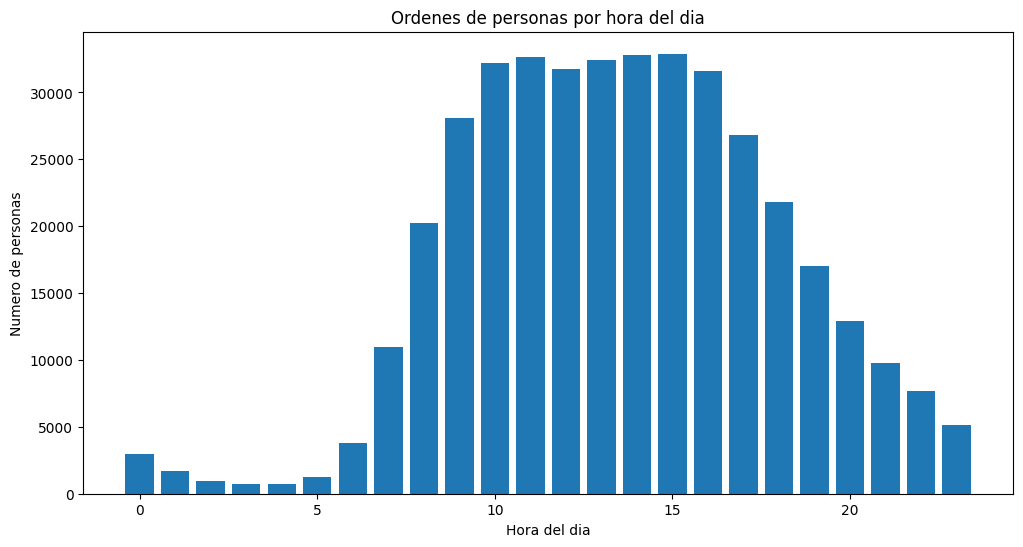

In [37]:
import matplotlib.pyplot as plt

order_per_hour = df_orders.groupby("order_hour_of_day")["user_id"].nunique().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(order_per_hour.index, order_per_hour.values)
plt.title('Ordenes de personas por hora del dia')
plt.xlabel('Hora del dia')
plt.ylabel('Numero de personas')
plt.show()

Escribe aquí tus conclusiones

entre las 10 y las 16 es cuando mas pedidos hay en la plataforma, entre las 0 y 6 de la mañana hay menos pedidos en la plataforma

### [A3] ¿Qué día de la semana compran víveres las personas?

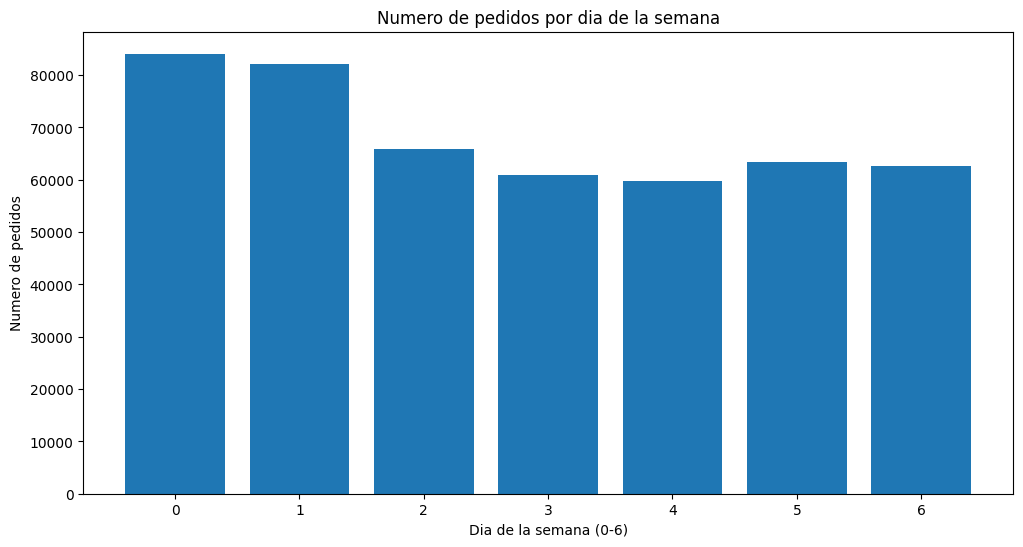

In [38]:
import matplotlib.pyplot as plt

order_per_day = df_orders["order_dow"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(order_per_day.index, order_per_day.values)
plt.title('Numero de pedidos por dia de la semana')
plt.xlabel('Dia de la semana (0-6)')
plt.ylabel('Numero de pedidos')
plt.show()


Escribe aquí tus conclusiones

los primeros 2 dias de la semana es cuando hay mas pedidos, el tercer y cuarto dia hay menos pedidos.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

Tiempo mínimo entre pedidos: 0.0 días
Tiempo máximo entre pedidos: 30.0 días


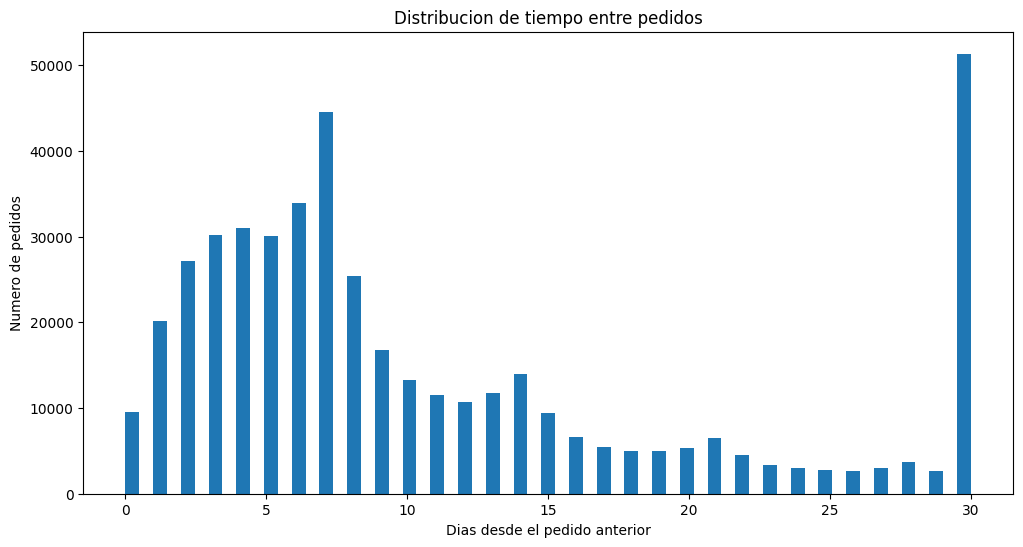

In [39]:
import matplotlib.pyplot as plt

waiting_time = df_orders["days_since_prior_order"].dropna()

min_wait = waiting_time.min()
max_wait = waiting_time.max()
print(f"Tiempo mínimo entre pedidos: {min_wait} días")
print(f"Tiempo máximo entre pedidos: {max_wait} días")

plt.figure(figsize=(12, 6))
plt.hist(waiting_time, bins = 61)
plt.title('Distribucion de tiempo entre pedidos')
plt.xlabel('Dias desde el pedido anterior')
plt.ylabel('Numero de pedidos')
plt.show()

Escribe aquí tus conclusiones

Hay una alta afluencia los primeros dias, de ahi baja y es constante del dia 10 al 29, en el dia 30 vuelve a subir

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [40]:
#filtramos por dias
miercoles = df_orders[df_orders['order_dow'] == 3]
sabados = df_orders[df_orders['order_dow'] == 6]

In [41]:
#pedidos por hora para cada dia
pedidos_miercoles = miercoles['order_hour_of_day'].value_counts().sort_index()
pedidos_sabados = sabados['order_hour_of_day'].value_counts().sort_index()

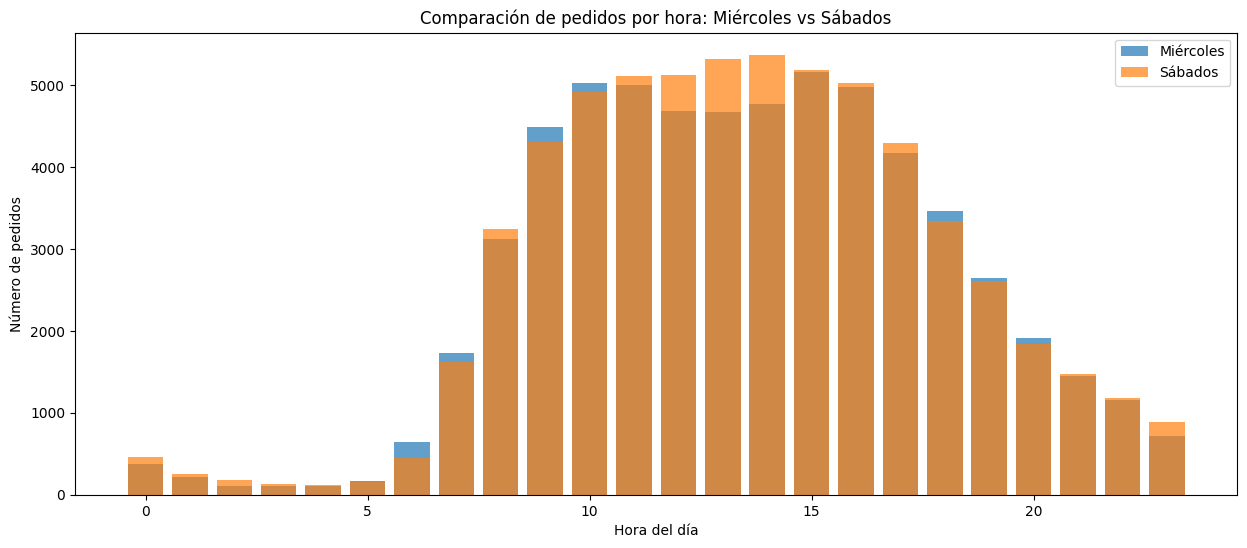

In [42]:
#graficamos
plt.figure(figsize=(15, 6))
plt.bar(pedidos_miercoles.index, pedidos_miercoles.values, alpha=0.7, label='Miércoles')
plt.bar(pedidos_sabados.index, pedidos_sabados.values, alpha=0.7, label='Sábados')
plt.title('Comparación de pedidos por hora: Miércoles vs Sábados')
plt.xlabel('Hora del día')
plt.ylabel('Número de pedidos')
plt.legend()
plt.show()

Escribe aquí tus conclusiones

En general podemos notar que hay mas pedidos los sabados que los miercoles, especialmente en horas de 11 a 14, sin embargo los miercoles son mas dominantes a las 6, 7, 9, 11, 18, 19 y 20

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [43]:
order_per_client = df_orders.groupby('user_id')['order_number'].max()

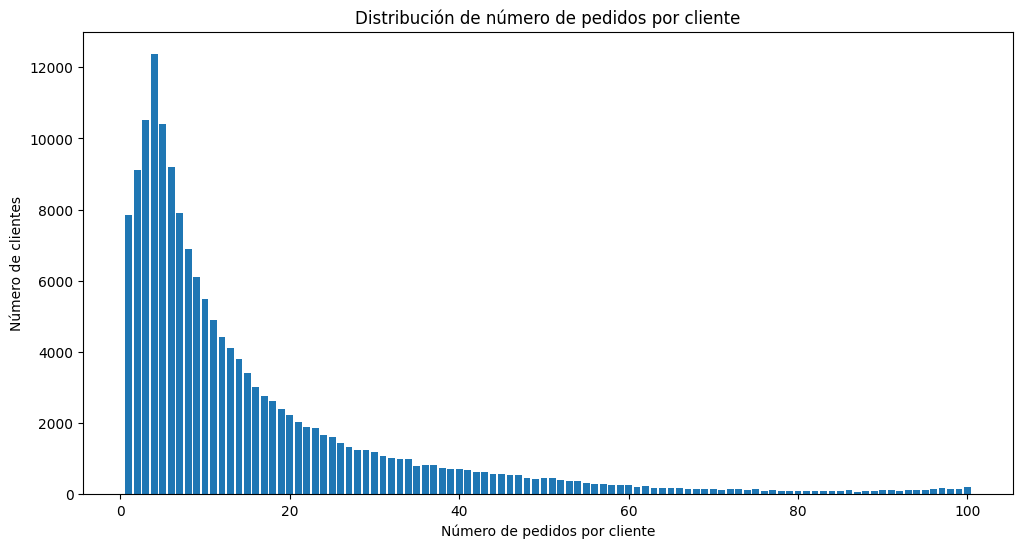

In [44]:
clientes_por_num_pedidos = order_per_client.value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.bar(clientes_por_num_pedidos.index, clientes_por_num_pedidos.values)
plt.xlabel('Número de pedidos por cliente')
plt.ylabel('Número de clientes')
plt.title('Distribución de número de pedidos por cliente')
plt.show()

Escribe aquí tus conclusiones

el pico de pedidos por cliente es 4, de 0 a 7 podemos considerarlo como el numero de pedidos mas habitual por cliente, de 8 en adelante va decreciendo 

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [45]:
conteo_productos = df_order_products['product_id'].value_counts()
top_products = conteo_productos.head(20)

In [46]:
top_products_df = top_products.reset_index()
top_products_df.columns = ['product_id', 'count']
top_products_final = top_products_df.merge(df_products[['product_id', 'product_name']], on='product_id')
top_products_final = top_products_final[['product_id', 'product_name', 'count']]
print(top_products_final)

    product_id              product_name  count
0        24852                    Banana  66050
1        13176    Bag of Organic Bananas  53297
2        21137      Organic Strawberries  37039
3        21903      Organic Baby Spinach  33971
4        47209      Organic Hass Avocado  29773
5        47766           Organic Avocado  24689
6        47626               Large Lemon  21495
7        16797              Strawberries  20018
8        26209                     Limes  19690
9        27845        Organic Whole Milk  19600
10       27966       Organic Raspberries  19197
11       22935      Organic Yellow Onion  15898
12       24964            Organic Garlic  15292
13       45007          Organic Zucchini  14584
14       39275       Organic Blueberries  13879
15       49683            Cucumber Kirby  13675
16       28204        Organic Fuji Apple  12544
17        5876             Organic Lemon  12232
18        8277  Apple Honeycrisp Organic  11993
19       40706    Organic Grape Tomatoes

Escribe aquí tus conclusiones

EL producto mas vendido son las bananas y el menos vendido es organic grape tomatoes

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [47]:
productos_por_pedido = df_order_products.groupby('order_id')['product_id'].count()

In [48]:
print("Número mínimo de productos por pedido:", productos_por_pedido.min())
print("Número máximo de productos por pedido:", productos_por_pedido.max())
print("Número promedio de productos por pedido:", productos_por_pedido.mean())
print("Mediana de productos por pedido:", productos_por_pedido.median())

Número mínimo de productos por pedido: 1
Número máximo de productos por pedido: 127
Número promedio de productos por pedido: 10.098983215049127
Mediana de productos por pedido: 8.0


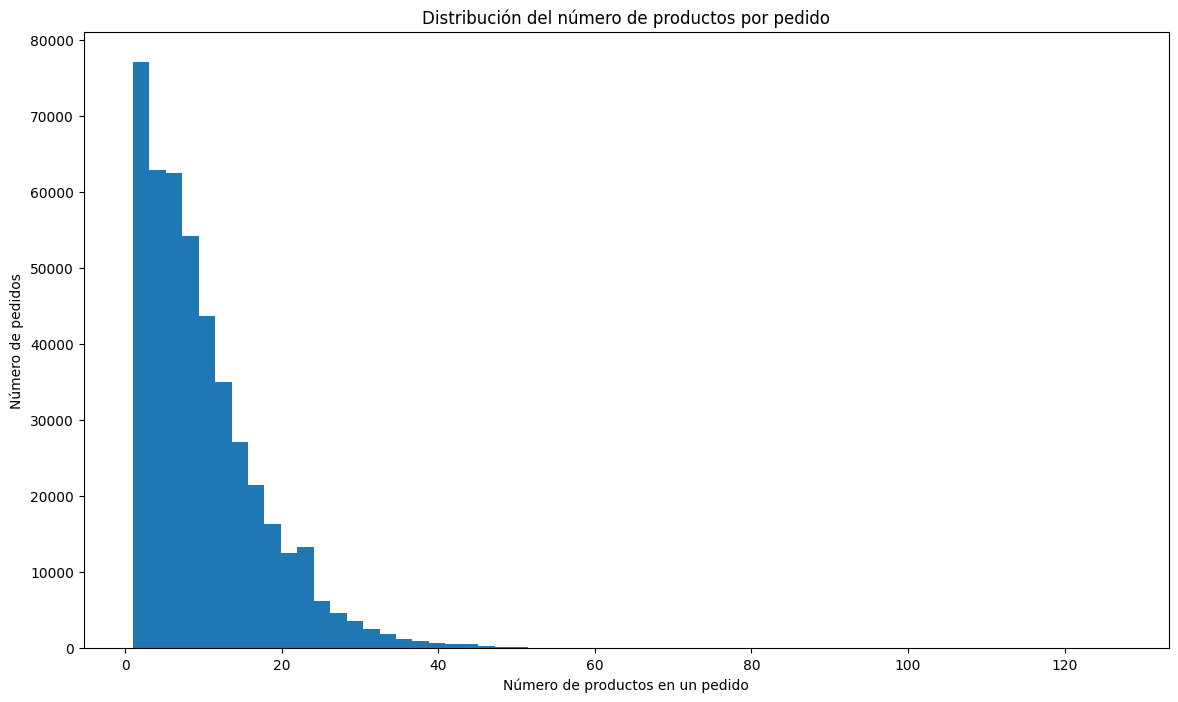

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
plt.hist(productos_por_pedido, bins=60)
plt.title('Distribución del número de productos por pedido')
plt.xlabel('Número de productos en un pedido')
plt.ylabel('Número de pedidos')
plt.show()


Escribe aquí tus conclusiones

La mayoria de gente solo hace 1 producto por , decreciendo considerablemente hasta 20, en 21, sube un poco y luego decrece nuevamente

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [50]:
reorders = df_order_products[df_order_products['reordered'] == 1]

In [51]:
top_reorders = reorders['product_id'].value_counts().head(20)
top_reorders_df = top_reorders.reset_index()
top_reorders_df.columns = ['product_id', 'veces_reordenado']

In [52]:
top_reorders_df = top_reorders_df.merge(df_products[['product_id', 'product_name']], on='product_id')

In [53]:
top_reorders_df = top_reorders_df[['product_id', 'product_name', 'veces_reordenado']]


print(top_reorders_df)

    product_id              product_name  veces_reordenado
0        24852                    Banana             55763
1        13176    Bag of Organic Bananas             44450
2        21137      Organic Strawberries             28639
3        21903      Organic Baby Spinach             26233
4        47209      Organic Hass Avocado             23629
5        47766           Organic Avocado             18743
6        27845        Organic Whole Milk             16251
7        47626               Large Lemon             15044
8        27966       Organic Raspberries             14748
9        16797              Strawberries             13945
10       26209                     Limes             13327
11       22935      Organic Yellow Onion             11145
12       24964            Organic Garlic             10411
13       45007          Organic Zucchini             10076
14       49683            Cucumber Kirby              9538
15       28204        Organic Fuji Apple              89

Escribe aquí tus conclusiones

el producto mas reodenado es la banana

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [54]:
total_pedidos_por_producto = df_order_products['product_id'].value_counts()

In [55]:
reordenes_por_producto = df_order_products[df_order_products['reordered'] == 1]['product_id'].value_counts()

In [56]:
productos = pd.concat([total_pedidos_por_producto, reordenes_por_producto], axis=1)
productos.columns = ['total_pedidos', 'veces_reordenado']
productos['veces_reordenado'] = productos['veces_reordenado'].fillna(0)
productos['proporcion_reorden'] = productos['veces_reordenado'] / productos['total_pedidos']
productos = productos.merge(df_products[['product_id', 'product_name']], left_index=True, right_on='product_id')
productos = productos[['product_id', 'product_name', 'total_pedidos', 'veces_reordenado', 'proporcion_reorden']]
productos.head(10)


,product_id,product_name,total_pedidos,veces_reordenado,proporcion_reorden
0,1,Chocolate Sandwich Cookies,280,158.0,0.564286
1,2,All-Seasons Salt,11,0.0,0.000000
2,3,Robust Golden Unsweetened Oolong Tea,42,31.0,0.738095
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,49,25.0,0.510204
6,7,Pure Coconut Water With Orange,2,1.0,0.500000
7,8,Cut Russet Potatoes Steam N' Mash,19,6.0,0.315789
8,9,Light Strawberry Blueberry Yogurt,21,16.0,0.761905
9,10,Sparkling Orange Juice & Prickly Pear Beverage,337,151.0,0.448071
10,11,Peach Mango Juice,16,10.0,0.625000
11,12,Chocolate Fudge Layer Cake,41,16.0,0.390244


Escribe aquí tus conclusiones

El producto mas reordenado es el chocolate sanwich cookies, el menos reordenado es el all-seasons salt, en cuestion de proporcion de reorden destaca el lightstrawberry blueberry yogurt que de 21 pedidos totales se reodeno 16 sin embargo esto no nos indica que sea el mas reordenado

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [57]:

pedidos_completos = df_order_products.merge(df_orders[['order_id', 'user_id']], on='order_id')
cliente_stats = pedidos_completos.groupby('user_id').agg({'product_id': 'count', 'reordered': 'sum'}).reset_index()

cliente_stats.columns = ['user_id', 'total_productos', 'productos_reordenados']
cliente_stats['proporcion_reorden'] = cliente_stats['productos_reordenados'] / cliente_stats['total_productos']

In [58]:
print(cliente_stats.head(10))

   user_id  total_productos  productos_reordenados  proporcion_reorden
0        2               26                      1            0.038462
1        4                2                      0            0.000000
2        5               12                      8            0.666667
3        6                4                      0            0.000000
4        7               14                     13            0.928571
5       11               15                      3            0.200000
6       12               12                      3            0.250000
7       13               23                     13            0.565217
8       14               61                     22            0.360656
9       15               13                      7            0.538462


Escribe aquí tus conclusiones

el usuario 7 tiene mayor proporcion de reorden, el usuario 4 tiene nula proporcion de reorden y asi mismo es el que menos productos ordeno, tambien el usuario 6 no tiene productos reordenados por tanto no tiene proporcion de reorden, el usuario que mas productos pidio fue el 14

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [59]:
primeros_productos = df_order_products[df_order_products['add_to_cart_order'] == 1]

conteo_primeros = primeros_productos['product_id'].value_counts().reset_index()
conteo_primeros.columns = ['product_id', 'veces_primero']

In [60]:
top_primeros = conteo_primeros.merge(df_products[['product_id', 'product_name']], on='product_id')

In [61]:
top_primeros_ordenado = top_primeros.sort_values('veces_primero', ascending=False)
top_20_primeros = top_primeros_ordenado.head(20)[['product_id', 'product_name', 'veces_primero']]
print("Top 20 productos agregados primero al carrito:")
print(top_20_primeros)

Top 20 productos agregados primero al carrito:
    product_id                 product_name  veces_primero
0        24852                       Banana          15562
1        13176       Bag of Organic Bananas          11026
2        27845           Organic Whole Milk           4363
3        21137         Organic Strawberries           3946
4        47209         Organic Hass Avocado           3390
5        21903         Organic Baby Spinach           3336
6        47766              Organic Avocado           3044
7        19660                 Spring Water           2336
8        16797                 Strawberries           2308
9        27966          Organic Raspberries           2024
10       44632   Sparkling Water Grapefruit           1914
11       49235          Organic Half & Half           1797
12       47626                  Large Lemon           1737
13         196                         Soda           1733
14       38689     Organic Reduced Fat Milk           1397
15       

Escribe aquí tus conclusiones

Nuevamente Bananas vuelve a destacar, ademas de ser el producto mas reordenado, es el que primero se añade al carrito, el que menos se añade primero en el top es organic yellow onion

### Conclusion general del proyecto:

In [62]:
print("Despues de hacer el analisis correspondiente de datos, pudimos obtener informacion de que horas del dia y que dias de la semana se ordena mas, cuales son los productos mas ordenados, cuales son los mas reordenados,cuales son los que se ordenan primero. parte de esta informacion se pudo graficar para mostrar de una manera mas visual los analisis obtenidos. Me duele la cabeza")

Despues de hacer el analisis correspondiente de datos, pudimos obtener informacion de que horas del dia y que dias de la semana se ordena mas, cuales son los productos mas ordenados, cuales son los mas reordenados,cuales son los que se ordenan primero. parte de esta informacion se pudo graficar para mostrar de una manera mas visual los analisis obtenidos. Me duele la cabeza
